# 01 Reproduce Input Object

Interactive first-pass check for the zebrafish retina AnnData object.

Run this notebook before the fidelity analyses to confirm that the `.h5ad` loads, metadata columns are correct, cell counts make biological sense, and existing UMAP coordinates reproduce.

## Setup

Use the `retina-fidelity` conda environment as the notebook kernel.

In [4]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
import yaml

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)
sc.settings.verbosity = 2

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "config" / "config.yaml").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT / "scripts"))

from fidelity_utils import (
    counts_table,
    ensure_output_dirs,
    load_config,
    resolve_metadata_columns,
    retinal_cell_type_mask,
    summarize_obs_columns,
)

print("Repo root:", REPO_ROOT)
print("scanpy", sc.__version__)
print("anndata", ad.__version__)

Repo root: /Users/louis/Desktop/lab/code/zebrafish-retina-similarity-analysis
scanpy 1.9.3
anndata 0.8.0


## Load Config And AnnData

In [5]:
CONFIG_PATH = REPO_ROOT / "config" / "config.yaml"
config = load_config(CONFIG_PATH)
tables_dir, figures_dir = ensure_output_dirs(config)

h5ad_path = Path(config["data"]["h5ad_path"])
if not h5ad_path.is_absolute():
    h5ad_path = REPO_ROOT / h5ad_path

print("Config:", CONFIG_PATH)
print("Input:", h5ad_path)
print("Tables:", tables_dir.resolve())
print("Figures:", figures_dir.resolve())

Config: /Users/louis/Desktop/lab/code/zebrafish-retina-similarity-analysis/config/config.yaml
Input: /Users/louis/Desktop/lab/code/zebrafish-retina-similarity-analysis/annotated_clustered_corrected_doubletRemoved_Zebrafishes.h5ad
Tables: /Users/louis/Desktop/lab/code/zebrafish-retina-similarity-analysis/notebooks/results/tables
Figures: /Users/louis/Desktop/lab/code/zebrafish-retina-similarity-analysis/notebooks/results/figures


In [6]:
adata = sc.read_h5ad(h5ad_path)
adata

AnnData object with n_obs × n_vars = 160875 × 24597
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'renamed_samples', 'predicted_doublets', 'leiden', 'celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'renamed_samples_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [7]:
print(f"cells: {adata.n_obs:,}")
print(f"genes: {adata.n_vars:,}")
print("raw present:", adata.raw is not None)
print("layers:", list(adata.layers.keys()))
print("obsm:", list(adata.obsm.keys()))
print("uns keys:", list(adata.uns.keys())[:30])

cells: 160,875
genes: 24,597
raw present: True
layers: []
obsm: ['X_pca', 'X_pca_harmony', 'X_umap']
uns keys: ['celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'renamed_samples_colors', 'umap']


## Inspect Metadata Columns

In [8]:
obs_summary = summarize_obs_columns(adata.obs)
obs_summary.to_csv(tables_dir / "obs_columns_summary.csv", index=False)
obs_summary

,column,dtype,n_unique,n_missing,top_values
0,sample,category,8,0,Zebra: 26638; TH44: 24387; TH57: 24297; TH54: 19750; TH55: 18787; TH71: 18015; TH56: 17260; TH115: 11741
1,n_genes_by_counts,int32,4845,0,1083: 164; 934: 153; 1023: 150; 878: 150; 1051: 149; 1013: 148; 992: 147; 904: 145; 1080: 144; 928: 143; 882: 142; 1150: 141
2,log1p_n_genes_by_counts,float64,4845,0,6.988413181999592: 164; 6.840546529288687: 153; 6.931471805599453: 150; 6.778784897685177: 150; 6.9584483932976555: 149; 6.921658184151129: 148; 6.900730664045173: 147; 6.80793...
3,total_counts,float32,15936,0,1708.0: 78; 1607.0: 74; 1710.0: 74; 1727.0: 73; 1511.0: 73; 1761.0: 72; 1765.0: 72; 1749.0: 71; 1547.0: 71; 1739.0: 71; 1879.0: 71; 1549.0: 70
4,log1p_total_counts,float32,15936,0,7.4436636: 78; 7.3827467: 74; 7.4448333: 74; 7.45472: 73; 7.3211884: 73; 7.474205: 72; 7.4764724: 72; 7.467371: 71; 7.344719: 71; 7.4616404: 71; 7.539027: 71; 7.34601: 70
5,pct_counts_in_top_50_genes,float64,139550,0,25.0: 94; 22.22222222222222: 78; 20.0: 76; 23.076923076923077: 48; 21.428571428571427: 43; 22.727272727272727: 41; 23.52941176470588: 38; 23.333333333333332: 32; 21.73913043478...
6,pct_counts_in_top_100_genes,float64,141207,0,33.33333333333333: 188; 30.76923076923077: 40; 31.57894736842105: 39; 30.0: 37; 31.25: 36; 28.57142857142857: 34; 31.818181818181817: 33; 25.0: 29; 35.714285714285715: 26; 36.3...
7,pct_counts_in_top_200_genes,float64,142702,0,50.0: 103; 42.857142857142854: 68; 45.45454545454545: 49; 44.44444444444444: 48; 40.0: 44; 46.15384615384615: 41; 46.666666666666664: 34; 41.66666666666667: 31; 45.0: 29; 43.75...
8,pct_counts_in_top_500_genes,float64,142977,0,66.66666666666666: 141; 75.0: 43; 60.0: 33; 65.0: 29; 70.0: 29; 68.42105263157895: 28; 64.70588235294117: 28; 64.28571428571429: 26; 63.1578947368421: 26; 71.42857142857143: 26...
9,total_counts_mt,float32,1813,0,93.0: 916; 87.0: 906; 98.0: 900; 81.0: 898; 82.0: 892; 104.0: 882; 84.0: 879; 80.0: 878; 102.0: 877; 96.0: 876; 99.0: 875; 91.0: 874


In [9]:
adata.obs.head()

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_genes,renamed_samples,predicted_doublets,leiden,celltype
AAACCAAAGCTTAACG-1,Zebra,1355,7.212294,3342.0,8.114624,31.119090,46.439258,58.228606,74.416517,42.0,3.761200,1.256732,1355,LD,False,3,PR precursors
AAACCAAAGTACGCCG-1,Zebra,1347,7.206377,3189.0,8.067776,29.883976,43.775478,56.663531,73.439950,22.0,3.135494,0.689871,1347,LD,False,3,PR precursors
AAACCATTCGCTCATT-1,Zebra,2107,7.653495,4138.0,8.328210,18.680522,26.993717,37.965201,56.379894,91.0,4.521789,2.199130,2107,LD,False,57,HC
AAACCCGCACCTCACG-1,Zebra,2074,7.637716,5581.0,8.627302,30.818850,38.864003,49.345995,66.385952,56.0,4.043051,1.003404,2074,LD,False,13,MG
AAACCCGCATCGGGAC-1,Zebra,1772,7.480428,4710.0,8.457656,26.624204,40.849257,53.121019,69.787686,42.0,3.761200,0.891720,1772,LD,False,3,PR precursors


## Choose Condition And Cell-Type Columns

Leave the overrides as `None` to use auto-detection. If the detected columns are wrong, set them here and rerun the next cells.

In [10]:
CONDITION_COLUMN = None
CELL_TYPE_COLUMN = None

if CONDITION_COLUMN is not None:
    config["metadata"]["condition_column"] = CONDITION_COLUMN
if CELL_TYPE_COLUMN is not None:
    config["metadata"]["cell_type_column"] = CELL_TYPE_COLUMN

condition_column, cell_type_column = resolve_metadata_columns(adata, config)
print("condition_column:", condition_column)
print("cell_type_column:", cell_type_column)

condition_column: renamed_samples
cell_type_column: celltype


In [11]:
display(adata.obs[condition_column].astype(str).value_counts().rename("n_cells").to_frame())
display(adata.obs[cell_type_column].astype(str).value_counts().rename("n_cells").to_frame())

,n_cells
renamed_samples,
Control,134237
NMDA,15424
LD,11214


,n_cells
celltype,
BC,64278
HC,19751
MG,18153
AC,15517
Cones,10923
Rod,9390
MGPC,5531
PR precursors,4934
RGC,4912


## Cell Counts By Condition And Cell Type

In [12]:
condition_order = config.get("metadata", {}).get("condition_order")

counts = counts_table(
    adata.obs,
    condition_column=condition_column,
    cell_type_column=cell_type_column,
    condition_order=condition_order,
)
counts.to_csv(tables_dir / "cell_counts_by_condition_cell_type.csv", index=False)
counts.head(30)

,cell_type,condition,n_cells
0,AC,Control,13751
1,AC,LD,342
2,AC,NMDA,1424
3,BC,Control,62885
4,BC,LD,545
5,BC,NMDA,848
6,Cones,Control,10127
7,Cones,LD,372
8,Cones,NMDA,424
9,Endothelial,Control,759


In [13]:
counts_wide = counts.pivot_table(
    index="cell_type",
    columns="condition",
    values="n_cells",
    fill_value=0,
    observed=False,
)
counts_wide.to_csv(tables_dir / "cell_counts_by_condition_cell_type_wide.csv")
counts_wide

condition,Control,LD,NMDA
cell_type,,,
AC,13751,342,1424
BC,62885,545,848
Cones,10127,372,424
Endothelial,759,0,3
HC,17989,692,1070
MG,8707,4835,4611
MGPC,1515,1743,2273
Melanocyte,360,0,3
Microglia_ImmuneCells,2335,16,34


In [14]:
retinal_mask = retinal_cell_type_mask(adata.obs, cell_type_column, config)
adata_retinal = adata[retinal_mask].copy()
print(f"retinal-focused cells: {adata_retinal.n_obs:,} / {adata.n_obs:,}")

retinal_counts = counts_table(
    adata_retinal.obs,
    condition_column=condition_column,
    cell_type_column=cell_type_column,
    condition_order=condition_order,
)
retinal_counts.to_csv(tables_dir / "retinal_cell_counts_by_condition_cell_type.csv", index=False)
retinal_counts.pivot_table(
    index="cell_type",
    columns="condition",
    values="n_cells",
    fill_value=0,
    observed=False,
)

retinal-focused cells: 153,389 / 160,875


condition,Control,LD,NMDA
cell_type,,,
AC,13751,342,1424
BC,62885,545,848
Cones,10127,372,424
HC,17989,692,1070
MG,8707,4835,4611
MGPC,1515,1743,2273
PR precursors,1175,1619,2140
RGC,4299,157,456
Rod,6384,886,2120


## Cell-Type Fractions By Condition

Fractions are calculated within each condition group, so each condition sums to 1 across the displayed cell types.

In [15]:
fractions = counts.copy()
fractions["fraction"] = fractions["n_cells"] / fractions.groupby("condition", observed=False)["n_cells"].transform("sum")
fractions.to_csv(tables_dir / "cell_type_fractions_by_condition.csv", index=False)

fractions_wide = fractions.pivot_table(
    index="cell_type",
    columns="condition",
    values="fraction",
    fill_value=0,
    observed=False,
)
fractions_wide.to_csv(tables_dir / "cell_type_fractions_by_condition_wide.csv")
fractions_wide

condition,Control,LD,NMDA
cell_type,,,
AC,0.102438,0.030498,0.092324
BC,0.468462,0.048600,0.054979
Cones,0.075441,0.033173,0.027490
Endothelial,0.005654,0.000000,0.000195
HC,0.134009,0.061709,0.069372
MG,0.064863,0.431157,0.298950
MGPC,0.011286,0.155431,0.147368
Melanocyte,0.002682,0.000000,0.000195
Microglia_ImmuneCells,0.017395,0.001427,0.002204


In [16]:
retinal_fractions = retinal_counts.copy()
retinal_fractions["fraction"] = retinal_fractions["n_cells"] / retinal_fractions.groupby("condition", observed=False)["n_cells"].transform("sum")
retinal_fractions.to_csv(tables_dir / "retinal_cell_type_fractions_by_condition.csv", index=False)

retinal_fractions_wide = retinal_fractions.pivot_table(
    index="cell_type",
    columns="condition",
    values="fraction",
    fill_value=0,
    observed=False,
)
retinal_fractions_wide.to_csv(tables_dir / "retinal_cell_type_fractions_by_condition_wide.csv")
retinal_fractions_wide

condition,Control,LD,NMDA
cell_type,,,
AC,0.108419,0.030560,0.092672
BC,0.495813,0.048700,0.055187
Cones,0.079846,0.033241,0.027593
HC,0.141833,0.061835,0.069634
MG,0.068650,0.432044,0.300078
MGPC,0.011945,0.155750,0.147924
PR precursors,0.009264,0.144670,0.139269
RGC,0.033895,0.014029,0.029676
Rod,0.050334,0.079171,0.137967


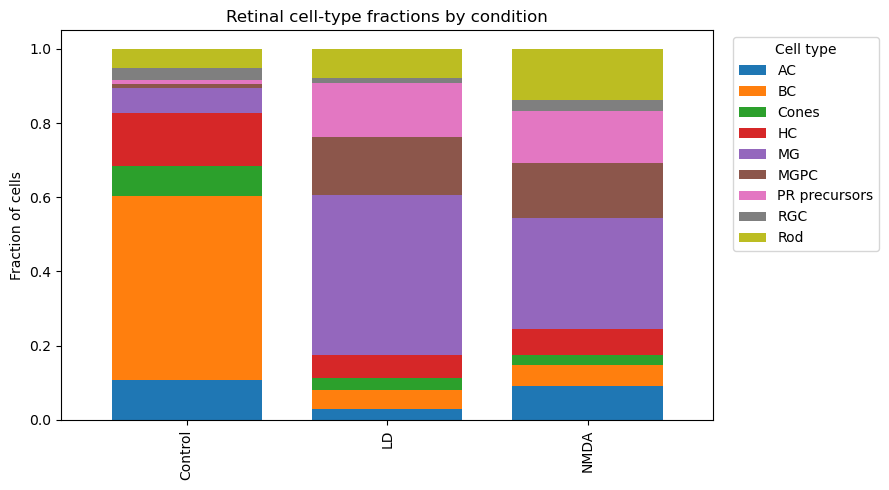

In [17]:
plot_fraction_wide = retinal_fractions.pivot_table(
    index="condition",
    columns="cell_type",
    values="fraction",
    fill_value=0,
    observed=False,
)
if condition_order is not None:
    ordered = [condition for condition in condition_order if condition in plot_fraction_wide.index]
    plot_fraction_wide = plot_fraction_wide.loc[ordered]

ax = plot_fraction_wide.plot(kind="bar", stacked=True, figsize=(9, 5), width=0.75)
ax.set_xlabel("")
ax.set_ylabel("Fraction of cells")
ax.set_title("Retinal cell-type fractions by condition")
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(figures_dir / "retinal_cell_type_fractions_by_condition.png", dpi=300, bbox_inches="tight")

## Plot Count Summary

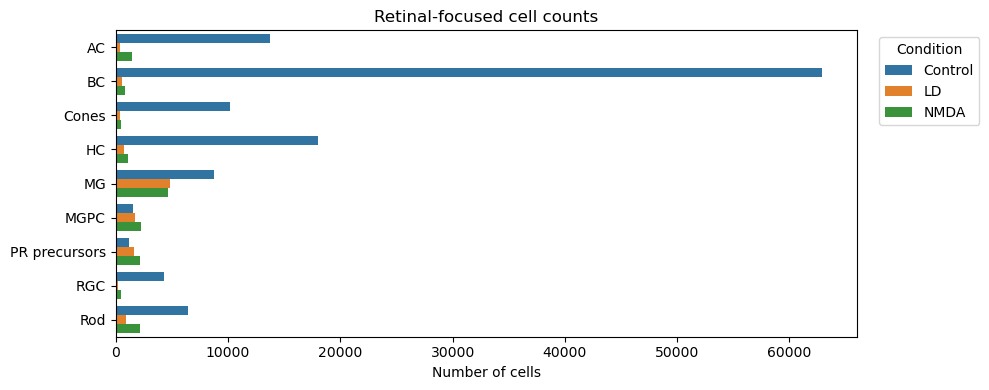

In [18]:
plot_counts = retinal_counts.copy()
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * plot_counts["cell_type"].nunique())))
sns.barplot(data=plot_counts, y="cell_type", x="n_cells", hue="condition", ax=ax)
ax.set_xlabel("Number of cells")
ax.set_ylabel("")
ax.set_title("Retinal-focused cell counts")
ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(figures_dir / "retinal_cell_counts_by_condition.png", dpi=300, bbox_inches="tight")

## Reproduce Existing UMAPs

These plots use existing `adata.obsm['X_umap']` coordinates. This notebook does not recompute preprocessing.

/Users/louis/miniforge3/envs/retina-fidelity/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


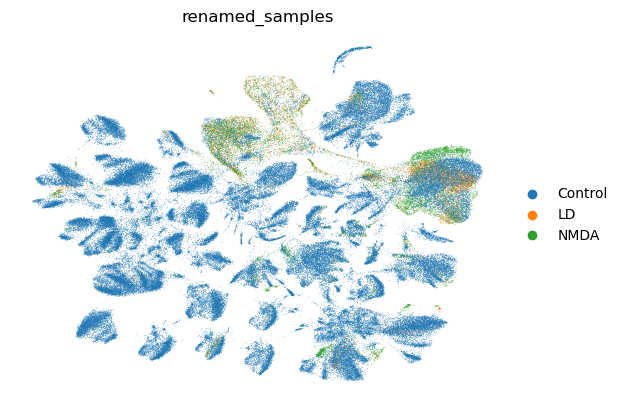

In [19]:
if "X_umap" not in adata.obsm:
    print("No X_umap found in adata.obsm; skip UMAP reproduction.")
else:
    sc.pl.umap(adata, color=condition_column, frameon=False, wspace=0.4)

/Users/louis/miniforge3/envs/retina-fidelity/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


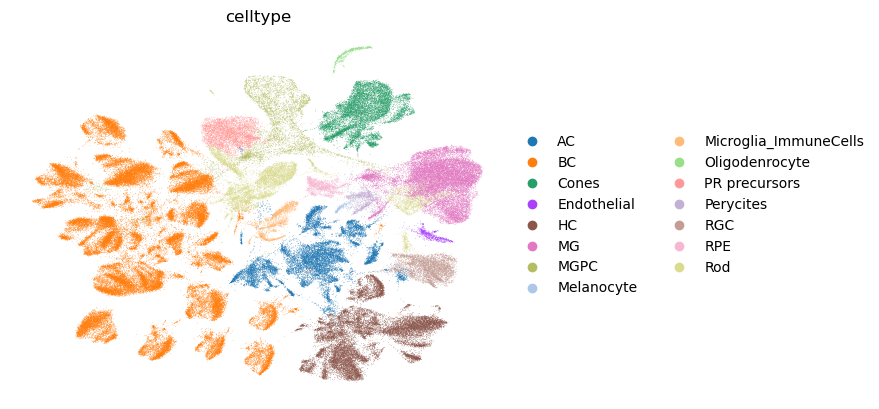

In [20]:
if "X_umap" in adata.obsm:
    sc.pl.umap(adata, color=cell_type_column, frameon=False, legend_loc="right margin")

/Users/louis/miniforge3/envs/retina-fidelity/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


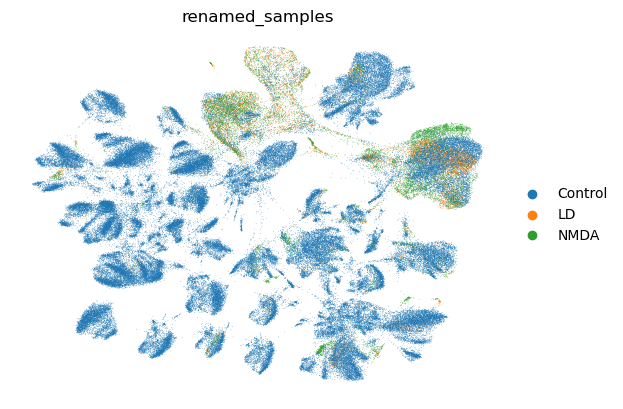

/Users/louis/miniforge3/envs/retina-fidelity/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


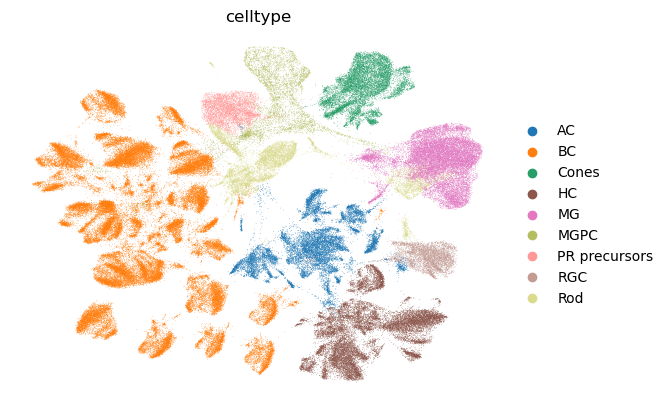

In [21]:
if "X_umap" in adata_retinal.obsm:
    sc.pl.umap(adata_retinal, color=condition_column, frameon=False, wspace=0.4)
    sc.pl.umap(adata_retinal, color=cell_type_column, frameon=False, legend_loc="right margin")

## Save Reproduction UMAPs

In [22]:
def save_umap(adata_obj, color, filename):
    if "X_umap" not in adata_obj.obsm:
        return
    sc.pl.umap(adata_obj, color=color, frameon=False, show=False)
    plt.savefig(figures_dir / filename, dpi=300, bbox_inches="tight")
    plt.close()

save_umap(adata, condition_column, "umap_condition.png")
save_umap(adata, cell_type_column, "umap_cell_type.png")
save_umap(adata_retinal, condition_column, "umap_condition_retinal.png")
save_umap(adata_retinal, cell_type_column, "umap_cell_type_retinal.png")

print("Saved UMAP figures to", figures_dir.resolve())

/Users/louis/miniforge3/envs/retina-fidelity/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/louis/miniforge3/envs/retina-fidelity/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/louis/miniforge3/envs/retina-fidelity/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/louis/miniforge3/envs/retina-fidelity/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP figures to /Users/louis/Desktop/lab/code/zebrafish-retina-similarity-analysis/notebooks/results/figures


## Write Detected Columns

Use these values to update `config/config.yaml` after confirming they are correct.

In [23]:
detected = pd.DataFrame(
    [
        {"role": "condition", "column": condition_column},
        {"role": "cell_type", "column": cell_type_column},
    ]
)
detected.to_csv(tables_dir / "detected_metadata_columns.csv", index=False)
detected

,role,column
0,condition,renamed_samples
1,cell_type,celltype
